In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [2]:
ruta = "../data/processed/datasetmodificado_clean.csv"

df = pd.read_csv(ruta)

df.head()

,AÑO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,2013.0,27,Chocó,145133.0,79.59,79.59,55.47,82.73,44.28,18.43,...,6.56,0.14,88.62,8.37,4.38,0.15,0.14,0.16,0.11,0.06
1,2017.0,27,Chocó,145765.0,79.20,79.19,54.05,80.16,48.97,22.19,...,9.14,0.28,88.14,11.68,5.35,2.23,0.28,3.14,1.39,0.38
2,2016.0,50,Meta,219565.0,92.40,92.28,56.26,90.78,77.27,43.97,...,5.57,0.18,91.88,9.22,5.21,0.86,0.18,0.84,1.23,0.25
3,2013.0,68,Santander,419596.0,93.40,93.28,60.45,92.92,80.27,48.09,...,3.41,0.47,95.30,5.58,4.41,2.04,0.47,1.48,3.29,1.35
4,2015.0,17,Caldas,194108.0,78.90,78.86,52.47,74.53,69.24,43.55,...,8.20,0.80,90.65,12.14,6.34,2.18,0.80,1.55,3.58,1.65


In [3]:
X = df.drop("DESERCIÓN", axis=1)

y = df["DESERCIÓN"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (24, 36)
Test: (7, 36)


In [7]:
from sklearn.preprocessing import StandardScaler

# Seleccionar solo columnas numéricas
X_train_numeric = X_train.select_dtypes(include=["number"])
X_test_numeric = X_test.select_dtypes(include=["number"])

# Escalamiento
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_numeric
)

X_test_scaled = scaler.transform(
    X_test_numeric
)

In [9]:

from sklearn.linear_model import LogisticRegression
import pandas as pd

# Convertir deserción en clases
y_train_clases = pd.cut(
    y_train,
    bins=[0, 2, 5, 100],
    labels=[0, 1, 2]
)

y_test_clases = pd.cut(
    y_test,
    bins=[0, 2, 5, 100],
    labels=[0, 1, 2]
)

# Modelo
lr_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

# Entrenamiento
lr_model.fit(
    X_train_scaled,
    y_train_clases
)

# Predicciones
y_pred_lr = lr_model.predict(
    X_test_scaled
)

In [10]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Convertir deserción en categorías
y_train_clases = pd.cut(
    y_train,
    bins=[0, 2, 5, 100],
    labels=[0, 1, 2]
)

y_test_clases = pd.cut(
    y_test,
    bins=[0, 2, 5, 100],
    labels=[0, 1, 2]
)

# Seleccionar solo columnas numéricas
X_train_numeric = X_train.select_dtypes(include=["number"])
X_test_numeric = X_test.select_dtypes(include=["number"])

# Modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Entrenamiento
rf_model.fit(
    X_train_numeric,
    y_train_clases
)

# Predicciones
y_pred_rf = rf_model.predict(
    X_test_numeric
)

In [12]:
from sklearn.metrics import accuracy_score

# Accuracy Logistic Regression
accuracy_lr = accuracy_score(
    y_test_clases,
    y_pred_lr
)

# Accuracy Random Forest
accuracy_rf = accuracy_score(
    y_test_clases,
    y_pred_rf
)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Logistic Regression Accuracy: 1.0000
Random Forest Accuracy: 0.8571


In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_clases,
        y_pred_lr,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         1

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test_clases, y_pred_rf,zero_division=0 ))

              precision    recall  f1-score   support

           1       0.86      1.00      0.92         6
           2       0.00      0.00      0.00         1

    accuracy                           0.86         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7



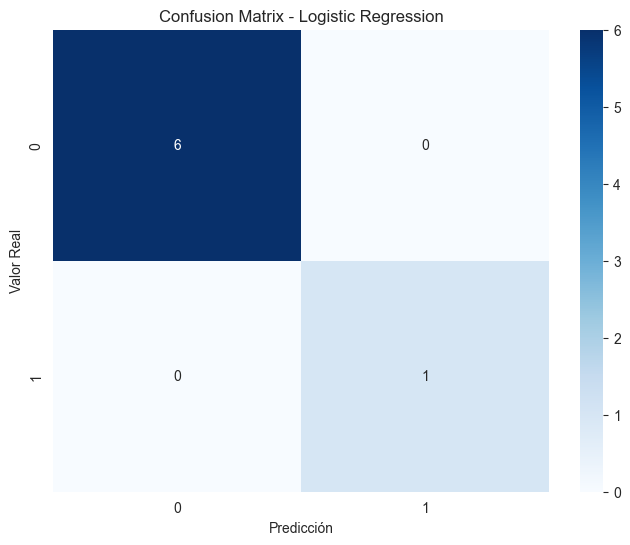

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión
cm_lr = confusion_matrix(
    y_test_clases,
    y_pred_lr
)

# Gráfico
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

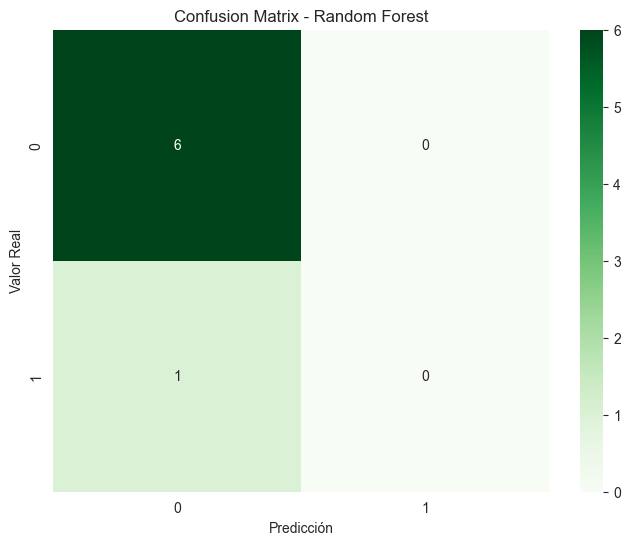

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test_clases, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [19]:
from sklearn.model_selection import cross_val_score

# Validación cruzada
cv_lr = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train_clases,
    cv=5
)

print("CV Logistic Regression:", cv_lr)
print("Media:", cv_lr.mean())

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


CV Logistic Regression: [0.6  1.   0.6  0.8  0.75]
Media: 0.75


In [21]:
from sklearn.model_selection import cross_val_score

cv_rf = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train_clases,
    cv=5
)

print("CV Random Forest:", cv_rf)
print("Media:", cv_rf.mean())

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


CV Random Forest: [1.   1.   0.8  0.8  0.75]
Media: 0.8699999999999999


In [22]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Cross Validation": [
        cv_lr.mean(),
        cv_rf.mean()
    ]
})

resultados

,Modelo,Accuracy,Cross Validation
0,Logistic Regression,1.000000,0.75
1,Random Forest,0.857143,0.87


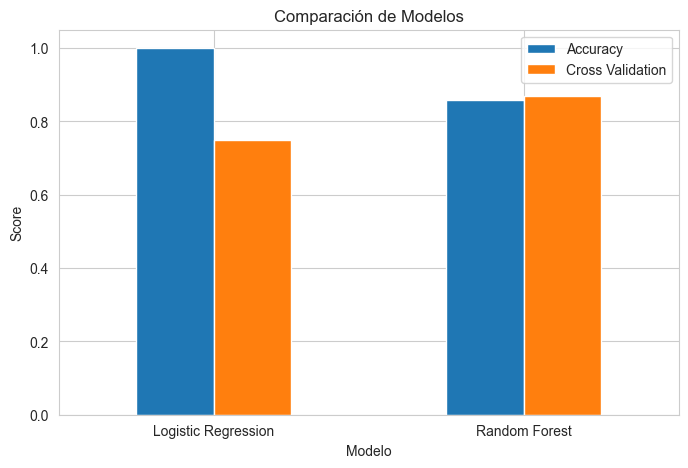

In [23]:
import matplotlib.pyplot as plt

resultados.plot(
    x="Modelo",
    y=["Accuracy", "Cross Validation"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparación de Modelos")

plt.xticks(rotation=0)

plt.ylabel("Score")

plt.show()

In [24]:
import pandas as pd

# Importancia de variables
importancias = pd.DataFrame({
    "Variable": X_train_numeric.columns,
    "Importancia": rf_model.feature_importances_
})

# Ordenar
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar resultados
importancias

,Variable,Importancia
16,DESERCIÓN_TRANSICIÓN,0.142747
17,DESERCIÓN_PRIMARIA,0.125177
18,DESERCIÓN_SECUNDARIA,0.101930
23,APROBACIÓN_SECUNDARIA,0.092807
19,DESERCIÓN_MEDIA,0.072608
9,COBERTURA_BRUTA,0.030393
6,COBERTURA_NETA_PRIMARIA,0.029292
3,TASA_MATRICULACIÓN_5_16,0.028855
1,CÓDIGO_DEPARTAMENTO,0.023941
5,COBERTURA_NETA_TRANSICIÓN,0.023929


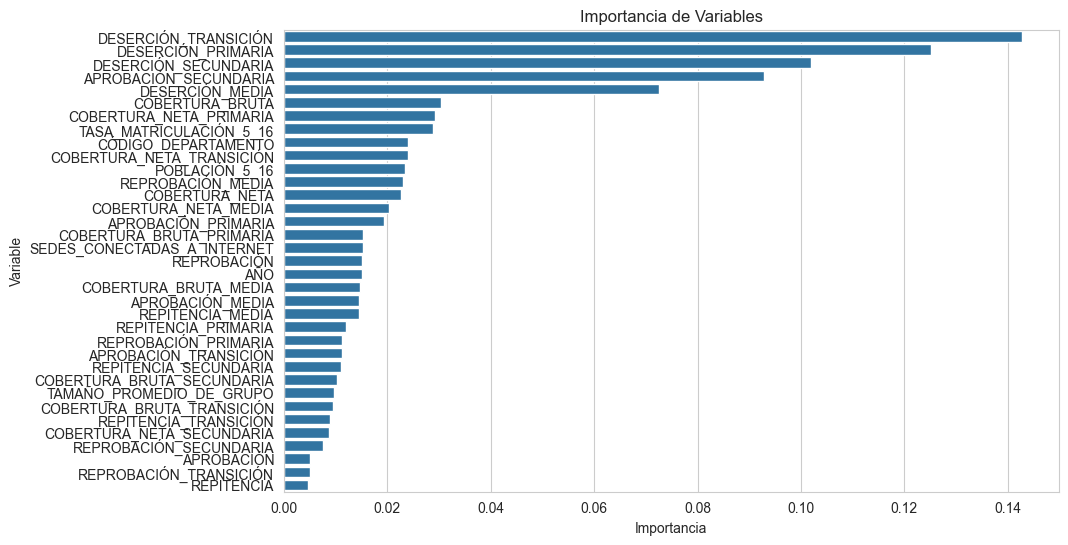

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de importancia
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de Variables")

plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

In [26]:
parametros = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# GridSearch
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parametros,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Entrenamiento solo con variables numéricas
grid.fit(
    X_train_numeric,
    y_train_clases
)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [28]:
print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor score:")
print(grid.best_score_)

Mejores parámetros:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Mejor score:
0.8333333333333334


In [29]:
from sklearn.metrics import accuracy_score

# Mejor modelo
best_model = grid.best_estimator_

# Predicciones
y_pred_best = best_model.predict(
    X_test_numeric
)

# Accuracy
accuracy_best = accuracy_score(
    y_test_clases,
    y_pred_best
)

print(f"Accuracy Mejor Modelo: {accuracy_best:.4f}")

Accuracy Mejor Modelo: 0.8571


In [30]:
##Guardar mejor modelo
import joblib

joblib.dump(
    best_model,
    "../models/best_random_forest.pkl"
)

print("Mejor modelo guardado")

Mejor modelo guardado
